# Vietnamese Speech Emotion Recognition (SER) - Live Inference & Evaluation

This notebook demonstrates the end-to-end inference and evaluation pipeline for the proposed Speech Emotion Recognition models on the ViSEC dataset. It operates strictly on the held-out Test set as defined by the speaker-independent `split_manifest.json`.

**Prerequisites:**
You must have already run `generate_splits.py` to create the manifest, and trained the models using their respective scripts to generate the checkpoints.


In [1]:
# ==================== 1. SETUP & LOAD ARTIFACTS ====================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import librosa
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Move to root to access all paths correctly as originally designed
if os.getcwd().endswith('internal'):
    os.chdir('..')

# Use absolute paths using src.config.paths
import sys
sys.path.append(os.path.abspath('.'))
from src.config.paths import BENCHMARK_RESULTS_PATH, ROOT_DIR

print("Loading Benchmark Results...")
if BENCHMARK_RESULTS_PATH.exists():
    with open(BENCHMARK_RESULTS_PATH, 'r', encoding='utf-8') as f:
        benchmark_data = json.load(f)
    emotion_labels = benchmark_data['emotion_labels']
    print(f"✓ Loaded benchmark results for {len(benchmark_data['ranked_results'])} models.")
else:
    print("❌ benchmark_results_gpu.json not found. Run benchmark_methods_gpu.py first.")
    emotion_labels = ['angry', 'happy', 'neutral', 'sad']

from typing import Any

def run_script(script: Path, args: list[str]) -> tuple[int, str, str]:
    import subprocess
    cmd = [sys.executable, str(script), *args]
    proc = subprocess.run(cmd, cwd=str(script.parent), capture_output=True, text=True)
    return proc.returncode, proc.stdout.strip(), proc.stderr.strip()

def extract_json_object(text: str) -> Any | None:
    import re
    text = text.strip()
    if not text:
        return None
    try:
        return json.loads(text)
    except Exception:
        pass
    candidates = re.findall(r"\{.*\}", text, flags=re.DOTALL)
    for candidate in reversed(candidates):
        try:
            return json.loads(candidate)
        except Exception:
            continue
    return None


Loading Benchmark Results...
✓ Loaded benchmark results for 3 models.


## Exploratory Data Analysis



Loading dataset for EDA...


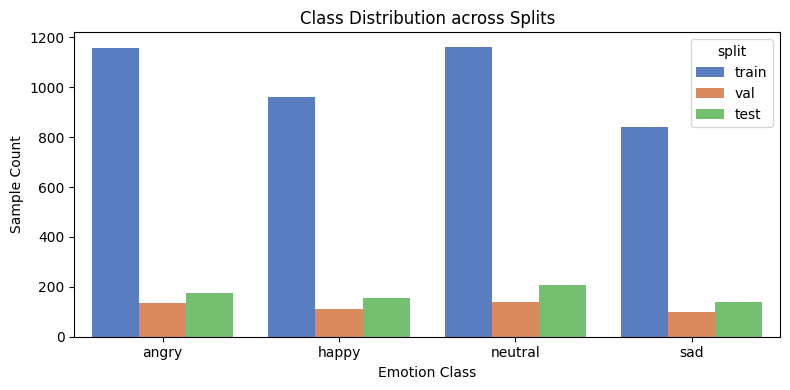

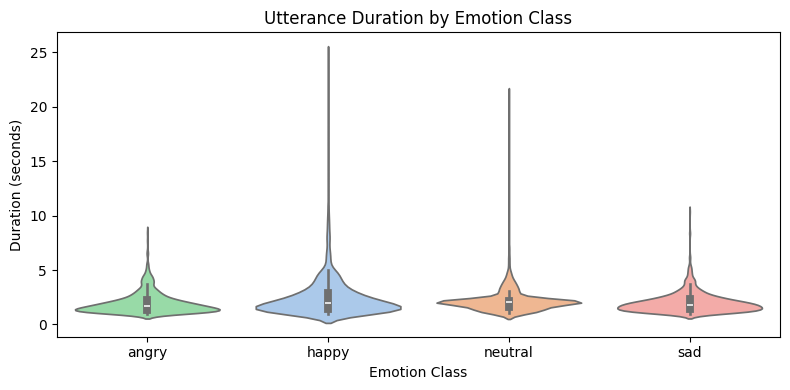

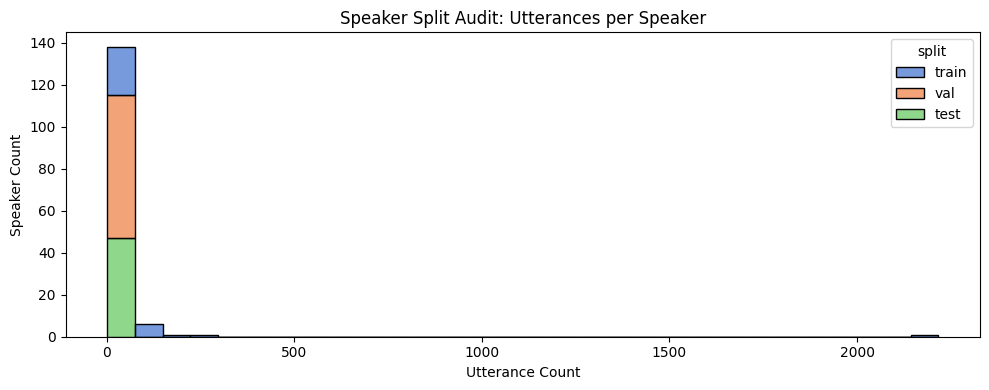

In [2]:
# ==================== 1.5. EXPLORATORY DATA ANALYSIS (EDA) ====================
from datasets import load_dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Loading dataset for EDA...")
dataset = load_dataset("hustep-lab/ViSEC", split="train", trust_remote_code=True)
df = dataset.to_pandas()

# Load manifest to get splits
manifest_path = ROOT_DIR / "split_manifest.json"
if manifest_path.exists():
    with open(manifest_path, "r") as f:
        manifest = json.load(f)
    
    train_idx = manifest["train_indices"]
    val_idx = manifest["val_indices"]
    test_idx = manifest["test_indices"]

    df['split'] = 'none'
    df.loc[train_idx, 'split'] = 'train'
    df.loc[val_idx, 'split'] = 'val'
    df.loc[test_idx, 'split'] = 'test'
else:
    df['split'] = 'train'

# 1. Class Distribution Plot
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='emotion', hue='split', order=['angry', 'happy', 'neutral', 'sad'], palette='muted')
plt.title("Class Distribution across Splits")
plt.ylabel("Sample Count")
plt.xlabel("Emotion Class")
plt.tight_layout()
plt.show()

# 2. Utterance Duration Plot
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x='emotion', y='duration', hue='emotion', palette='pastel', order=['angry', 'happy', 'neutral', 'sad'], legend=False)
plt.title("Utterance Duration by Emotion Class")
plt.ylabel("Duration (seconds)")
plt.xlabel("Emotion Class")
plt.tight_layout()
plt.show()

# 3. Speaker Split Audit
speaker_counts = df.groupby(['speaker_id', 'split']).size().reset_index(name='count')
plt.figure(figsize=(10, 4))
sns.histplot(data=speaker_counts, x='count', hue='split', multiple='stack', bins=30, palette='muted')
plt.title("Speaker Split Audit: Utterances per Speaker")
plt.xlabel("Utterance Count")
plt.ylabel("Speaker Count")
plt.tight_layout()
plt.show()


## Results Summary




--- Confusion Matrices ---


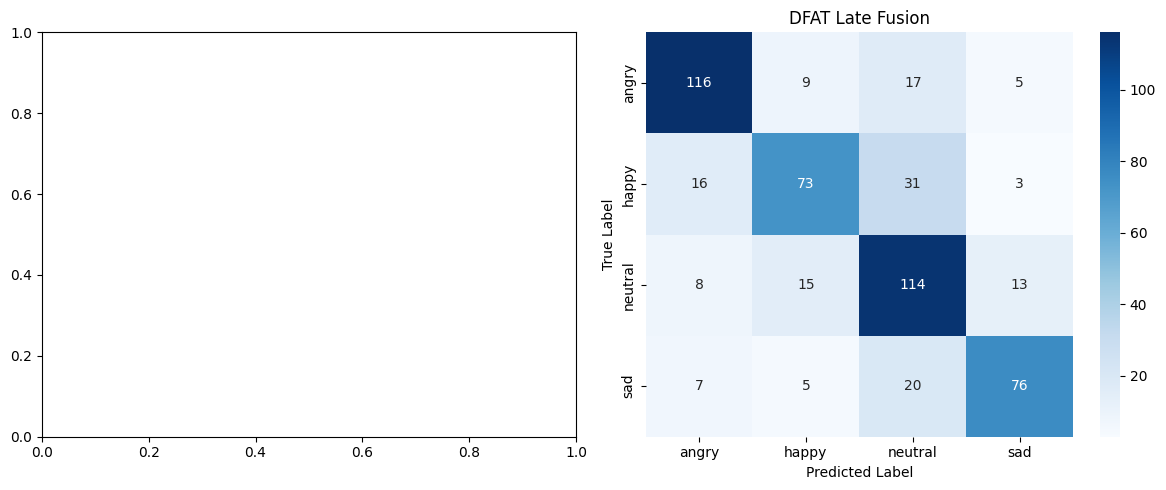

In [3]:
# ==================== 2. CONFUSION MATRICES ====================
if BENCHMARK_RESULTS_PATH.exists():
    print("\n--- Confusion Matrices ---")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for idx, (ax, model_name) in enumerate(zip(axes, ["ECAPA-TDNN (simplified implementation)", "DFAT Late Fusion"])):
        # Find model in benchmark
        model_res = next((r for r in benchmark_data['ranked_results'] if r['method'] == model_name), None)
        if model_res and 'confusion_matrix' in model_res['representative_run']:
            cm = np.array(model_res['representative_run']['confusion_matrix'])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                        xticklabels=emotion_labels, yticklabels=emotion_labels, ax=ax)
            ax.set_title(model_name)
            ax.set_ylabel('True Label')
            ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


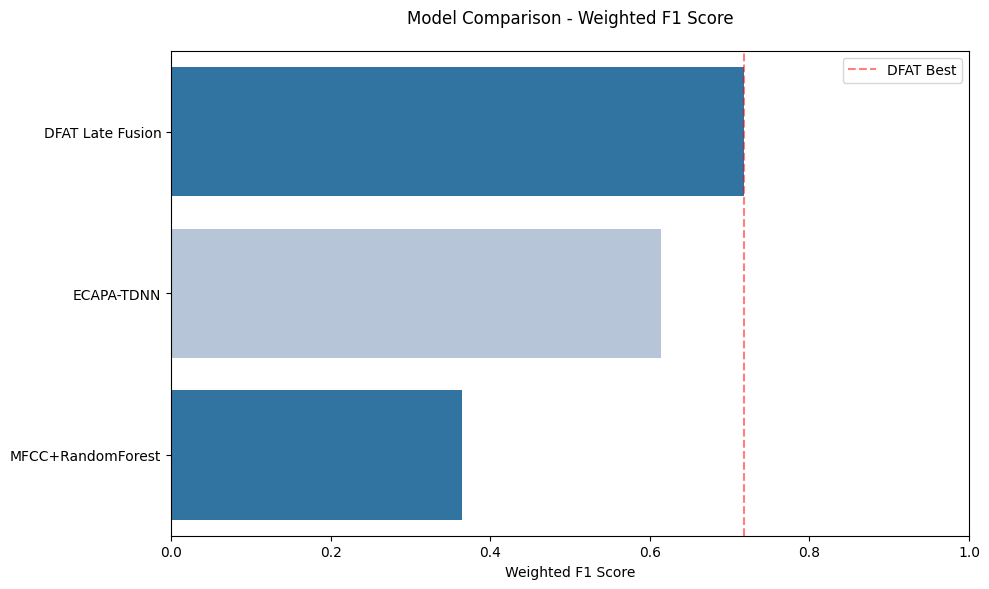

In [4]:
# ==================== 3. MODEL COMPARISON CHART ====================
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

benchmark_path = ROOT_DIR / "benchmark_results_gpu.json"
if benchmark_path.exists():
    with open(benchmark_path, 'r') as f:
        data = json.load(f)
    
    primary = ["MFCC+RandomForest", "ECAPA-TDNN (simplified implementation)", "DFAT Late Fusion"]
    methods = []
    wf1s = []
    colors = []
    
    for r in data.get("ranked_results", []):
        methods.append(r["method"])
        wf1s.append(r.get("f1_weighted_mean", 0))
        colors.append("#1f77b4" if r["method"] in primary else "#b0c4de")
        
    plt.figure(figsize=(10, 6))
    sns.barplot(x=wf1s, y=methods, palette=colors)
    plt.title("Model Comparison - Weighted F1 Score", pad=20)
    plt.xlabel("Weighted F1 Score")
    plt.xlim(0, 1.0)
    
    best_wf1 = max(wf1s) if wf1s else 0
    plt.axvline(x=best_wf1, color='red', linestyle='--', alpha=0.5, label='DFAT Best')
    plt.legend()
    plt.tight_layout()
    
    # Save to report_images
    Path("report_images").mkdir(exist_ok=True)
    plt.savefig("report_images/model_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("benchmark_results_gpu.json not found. Run benchmark_methods_gpu.py first.")


In [5]:
# ==================== 4. ABLATION STUDY RESULTS ====================
import pandas as pd

ablation_path = ROOT_DIR / "DFAT_Hybrid_Fusion" / "ablation_results.json"
if ablation_path.exists():
    with open(ablation_path, 'r') as f:
        data = json.load(f)
        
    records = []
    for r in data.get("ablation_results", []):
        ens = r.get("ensemble", {})
        records.append({
            "Configuration": r["config"],
            "Weighted F1": ens.get("f1_weighted", 0),
            "Macro F1": ens.get("f1_macro", 0),
            "Accuracy": ens.get("accuracy", 0)
        })
        
    df_ablation = pd.DataFrame(records)
    from IPython.display import display
    display(df_ablation.style.background_gradient(cmap='Blues', subset=['Weighted F1']))
else:
    print("Ablation results not found. Run ablation_study.py first.")


,Configuration,Weighted F1,Macro F1,Accuracy
0,Acoustic-only (WavLM),0.432900,0.427800,0.435600
1,Linguistic-only (Whisper-small + PhoBERT),0.336400,0.334900,0.344700
2,Early Fusion (Concat 1536-d),0.399500,0.393700,0.399600
3,Late Fusion (stream-level),0.340800,0.338300,0.365500
4,Linguistic-only (Whisper-tiny + PhoBERT),0.262400,0.251200,0.270800
5,Early Fusion (Whisper-tiny),0.404400,0.397200,0.407200
6,Early Fusion + 10% synthetic noise,0.428000,0.421600,0.429900
7,Early Fusion + 20% synthetic noise,0.424200,0.417900,0.428000
8,Early Fusion + 30% synthetic noise,0.416500,0.416900,0.416700


In [6]:
# ==================== 5. LIVE INFERENCE DEMO ====================
demo_audio = ROOT_DIR / "sample_visec.wav"

def try_predict_ecapa(audio_path: Path) -> Any | None:
    script = ROOT_DIR / "ECAPA" / "predict_emotion.py"
    model_dir = ROOT_DIR / "ECAPA" / "emotion_model"

    if not script.exists():
        print("ECAPA predict script not found.")
        return None

    rc, out, err = run_script(script, [str(audio_path), "--model_dir", str(model_dir)])
    if rc != 0:
        print("ECAPA script failed:")
        print(err or out)
        return None

    parsed = extract_json_object(out)
    print("ECAPA raw output:")
    print(out)
    return parsed if parsed is not None else out


def try_predict_dfat(audio_path: Path) -> Any | None:
    script = ROOT_DIR / "DFAT_Hybrid_Fusion" / "predict_dualstream.py"
    model_dir = ROOT_DIR / "DFAT_Hybrid_Fusion" / "dualstream_model"

    if not script.exists():
        print("DFAT predict script not found.")
        return None

    rc, out, err = run_script(script, ["--audio_file", str(audio_path), "--model_dir", str(model_dir)])
    if rc != 0:
        print("DFAT script failed:")
        print(err or out)
        return None

    parsed = extract_json_object(out)
    print("DFAT raw output:")
    print(out)
    return parsed if parsed is not None else out


if demo_audio.exists():
    print(f"Sample audio: {demo_audio}")
    import IPython.display as ipd
    from IPython.display import display
    display(ipd.Audio(str(demo_audio)))
    
    print("\n--- Running ECAPA-TDNN Inference ---")
    ecapa_pred = try_predict_ecapa(demo_audio)
    
    print("\n--- Running DFAT Late Fusion Inference ---")
    dfat_pred = try_predict_dfat(demo_audio)
else:
    print("sample_visec.wav is missing; skip demo inference.")


Sample audio: /mnt/12bc61a2-ddc5-4be8-b8be-bbd99dc6d141/AI engineer/Study/Speech-Emotions-Recognition/sample_visec.wav



--- Running ECAPA-TDNN Inference ---


ECAPA raw output:
{"angry": 9.920432830767822e-07, "happy": 0.9994409680366516, "neutral": 0.00016454940487165004, "sad": 0.0003935198183171451}

--- Running DFAT Late Fusion Inference ---


DFAT script failed:
Some weights of the model checkpoint at microsoft/wavlm-base-plus were not used when initializing WavLMModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing WavLMModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WavLMModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of WavLMModel were not initialized from the model checkpoint at microsoft/wavlm-base-plus and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to 